# Prediction results overview

Visualises `output_data/results/metrics.tsv` and `fold_scores.tsv` produced by `invoke run-predict`.

Run via `invoke run-notebooks` — figures are saved to `output_data/`.

In [1]:
import os
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd

OUTPUT_DIR = Path(os.environ.get("OUTPUT_DATA_DIR", "../output_data"))
RESULTS_DIR = OUTPUT_DIR / "results"

metrics = pd.read_csv(RESULTS_DIR / "metrics.tsv", sep="\t")
folds   = pd.read_csv(RESULTS_DIR / "fold_scores.tsv", sep="\t")

print(metrics.to_string(index=False))

 condition model           task    target  balanced_accuracy_mean  balanced_accuracy_std  p_vs_chance  p_eeg_only_vs_fmri_only  p_eeg_only_vs_multimodal  p_fmri_only_vs_multimodal
  eeg_only ridge classification diagnosis                    0.50               0.447214     0.584158                 0.621308                  0.748868                   0.070484
 fmri_only ridge classification diagnosis                    0.60               0.200000     0.495050                 0.621308                  0.748868                   0.070484
multimodal ridge classification diagnosis                    0.45               0.291548     0.673267                 0.621308                  0.748868                   0.070484


In [2]:
# Detect primary metric
task = metrics["task"].iloc[0]
primary = "balanced_accuracy" if task == "classification" else "pearson_r"
primary_label = {
    "balanced_accuracy": "Balanced accuracy",
    "pearson_r": "Pearson r",
    "r2": "R²",
    "mae": "MAE",
}[primary]

CONDITIONS   = ["eeg_only", "fmri_only", "multimodal"]
LABELS       = ["EEG only", "fMRI only", "Multimodal"]
COLORS       = ["#4C72B0", "#DD8452", "#55A868"]
target_col   = metrics["target"].iloc[0]
model_name   = metrics["model"].iloc[0]

## Mean score per condition

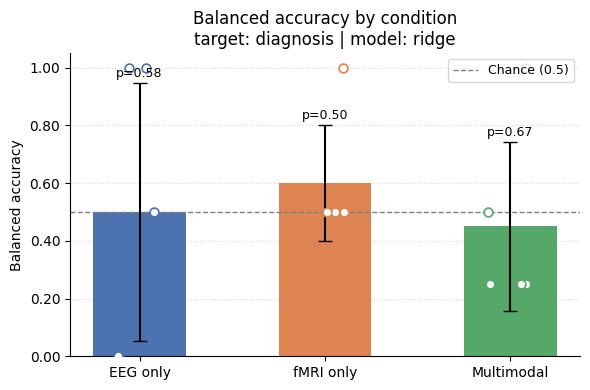

In [3]:
fold_data = {
    cond: folds[(folds["condition"] == cond) & (folds["metric"] == primary)]["value"].values
    for cond in CONDITIONS
}

means = [metrics.loc[metrics["condition"] == c, f"{primary}_mean"].values[0] for c in CONDITIONS]
stds  = [metrics.loc[metrics["condition"] == c, f"{primary}_std"].values[0]  for c in CONDITIONS]

fig, ax = plt.subplots(figsize=(6, 4))

x = np.arange(len(CONDITIONS))
bars = ax.bar(x, means, yerr=stds, width=0.5, color=COLORS,
              capsize=5, error_kw=dict(elinewidth=1.5), zorder=2)

# Overlay individual fold scores
rng = np.random.default_rng(0)
for i, cond in enumerate(CONDITIONS):
    jitter = rng.uniform(-0.12, 0.12, len(fold_data[cond]))
    ax.scatter(x[i] + jitter, fold_data[cond],
               color="white", edgecolors=COLORS[i], linewidths=1.2,
               s=40, zorder=3)

# Chance line for classification
if task == "classification":
    ax.axhline(0.5, color="grey", linestyle="--", linewidth=1, label="Chance (0.5)")
    ax.legend(fontsize=9)

# p-value vs chance annotations
for i, cond in enumerate(CONDITIONS):
    p = metrics.loc[metrics["condition"] == cond, "p_vs_chance"].values[0]
    stars = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else f"p={p:.2f}"
    ax.text(x[i], means[i] + stds[i] + 0.01, stars,
            ha="center", va="bottom", fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(LABELS)
ax.set_ylabel(primary_label)
ax.set_title(f"{primary_label} by condition\ntarget: {target_col} | model: {model_name}")
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.2f"))
ax.grid(axis="y", linestyle=":", alpha=0.5, zorder=0)
ax.spines[["top", "right"]].set_visible(False)

fig.tight_layout()
fig.savefig(OUTPUT_DIR / "scores_by_condition.png", dpi=150)
plt.show()

## Per-fold score distribution

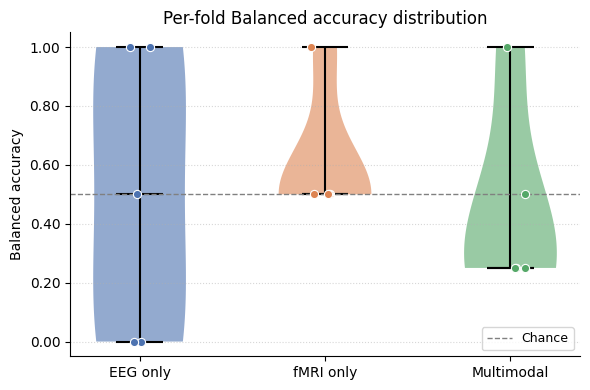

In [4]:
fig, ax = plt.subplots(figsize=(6, 4))

parts = ax.violinplot(
    [fold_data[c] for c in CONDITIONS],
    positions=x, widths=0.5, showmedians=True
)
for pc, color in zip(parts["bodies"], COLORS):
    pc.set_facecolor(color)
    pc.set_alpha(0.6)
parts["cmedians"].set_color("black")
parts["cbars"].set_color("black")
parts["cmins"].set_color("black")
parts["cmaxes"].set_color("black")

for i, cond in enumerate(CONDITIONS):
    jitter = rng.uniform(-0.08, 0.08, len(fold_data[cond]))
    ax.scatter(x[i] + jitter, fold_data[cond],
               color=COLORS[i], edgecolors="white", linewidths=0.8, s=35, zorder=3)

if task == "classification":
    ax.axhline(0.5, color="grey", linestyle="--", linewidth=1, label="Chance")
    ax.legend(fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(LABELS)
ax.set_ylabel(primary_label)
ax.set_title(f"Per-fold {primary_label} distribution")
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.2f"))
ax.grid(axis="y", linestyle=":", alpha=0.5)
ax.spines[["top", "right"]].set_visible(False)

fig.tight_layout()
fig.savefig(OUTPUT_DIR / "fold_distribution.png", dpi=150)
plt.show()

## Significance summary

In [5]:
def fmt_p(p):
    if p < 0.001: return f"{p:.2e} ***"
    if p < 0.01:  return f"{p:.3f} **"
    if p < 0.05:  return f"{p:.3f} *"
    return f"{p:.3f}"

rows = []
for cond, label in zip(CONDITIONS, LABELS):
    row = metrics[metrics["condition"] == cond].iloc[0]
    rows.append({
        "Condition": label,
        f"{primary_label} mean ± std": f"{row[f'{primary}_mean']:.3f} ± {row[f'{primary}_std']:.3f}",
        "p vs chance": fmt_p(row["p_vs_chance"]),
    })

summary = pd.DataFrame(rows).set_index("Condition")

# Paired comparisons (same for all rows — pick from first row)
r0 = metrics.iloc[0]
paired = pd.DataFrame([
    {"Comparison": "EEG only vs fMRI only",   "p (paired t-test)": fmt_p(r0["p_eeg_only_vs_fmri_only"])},
    {"Comparison": "EEG only vs Multimodal",  "p (paired t-test)": fmt_p(r0["p_eeg_only_vs_multimodal"])},
    {"Comparison": "fMRI only vs Multimodal", "p (paired t-test)": fmt_p(r0["p_fmri_only_vs_multimodal"])},
]).set_index("Comparison")

print("=== Per-condition ===")
print(summary.to_string())
print()
print("=== Paired comparisons ===")
print(paired.to_string())

=== Per-condition ===
           Balanced accuracy mean ± std p vs chance
Condition                                          
EEG only                  0.500 ± 0.447       0.584
fMRI only                 0.600 ± 0.200       0.495
Multimodal                0.450 ± 0.292       0.673

=== Paired comparisons ===
                        p (paired t-test)
Comparison                               
EEG only vs fMRI only               0.621
EEG only vs Multimodal              0.749
fMRI only vs Multimodal             0.070
